# Artificial Neural Network
![ANN](ann.jpg) 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# Original data (age and salary)
X = np.array([[22, 50000], [25, 60000], [47, 120000], [52, 130000], [46, 115000],
              [56, 150000], [48, 110000], [55, 140000], [22, 50000], [23, 55000], 
              [54, 135000], [48, 110000]])

# Labels (0 for 'Not Purchased', 1 for 'Purchased')
Y = np.array([[0], [0], [1], [1], [1], [1], [1], [1], [0], [0], [1], [1]])

In [3]:
# Min-Max Normalization of the data (age and salary)
X_min = np.min(X, axis=0)
X_max = np.max(X, axis=0)
X_normalized = (X - X_min) / (X_max - X_min)

# Check normalized data
print("Normalized Data (Age and Salary):\n", X_normalized)

Normalized Data (Age and Salary):
 [[0.         0.        ]
 [0.08823529 0.1       ]
 [0.73529412 0.7       ]
 [0.88235294 0.8       ]
 [0.70588235 0.65      ]
 [1.         1.        ]
 [0.76470588 0.6       ]
 [0.97058824 0.9       ]
 [0.         0.        ]
 [0.02941176 0.05      ]
 [0.94117647 0.85      ]
 [0.76470588 0.6       ]]


In [4]:
# Activation functions
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Neural network architecture
input_layer_neurons = X_normalized.shape[1]  # 2 input features (normalized age, salary)
hidden_layer_neurons = 3  # 2 neurons in the hidden layer
output_neuron = 1  # Binary classification (output 0 or 1)

In [5]:
# Initialize weights and biases
np.random.seed(42)
W1 = np.random.randn(input_layer_neurons, hidden_layer_neurons)
b1 = np.zeros((1, hidden_layer_neurons))
W2 = np.random.randn(hidden_layer_neurons, output_neuron)
b2 = np.zeros((1, output_neuron))

# Training parameters
learning_rate = 0.1
epochs = 10000


In [6]:
# Training the neural network
losses = []
accuracies = []  # To store accuracies
for epoch in range(epochs):
    # Forward Propagation
    Z1 = np.dot(X_normalized, W1) + b1
    A1 = relu(Z1)  # ReLU activation in the hidden layer
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)  # Sigmoid activation in the output layer
    
    # Compute the loss (binary cross-entropy)
    loss = -np.mean(Y * np.log(A2) + (1 - Y) * np.log(1 - A2))
    losses.append(loss)
    
    # Backward Propagation
    dA2 = A2 - Y
    dZ2 = dA2
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)  # Using ReLU derivative
    dW1 = np.dot(X_normalized.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    
    # Update weights and biases
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    
    # Calculate accuracy
    predictions = A2 > 0.5
    accuracy = np.mean(predictions == Y)
    accuracies.append(accuracy)
    
    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, Loss: {loss}, Accuracy: {accuracy * 100:.2f}%')

Epoch 0, Loss: 0.3166667146178543, Accuracy: 83.33%
Epoch 1000, Loss: 0.000219432098497387, Accuracy: 100.00%
Epoch 2000, Loss: 9.522540063052754e-05, Accuracy: 100.00%
Epoch 3000, Loss: 5.901513033458388e-05, Accuracy: 100.00%
Epoch 4000, Loss: 4.2178661806687734e-05, Accuracy: 100.00%
Epoch 5000, Loss: 3.2563453636974217e-05, Accuracy: 100.00%
Epoch 6000, Loss: 2.6386824178852442e-05, Accuracy: 100.00%
Epoch 7000, Loss: 2.210344632700665e-05, Accuracy: 100.00%
Epoch 8000, Loss: 1.8968544797808912e-05, Accuracy: 100.00%
Epoch 9000, Loss: 1.658048242080548e-05, Accuracy: 100.00%


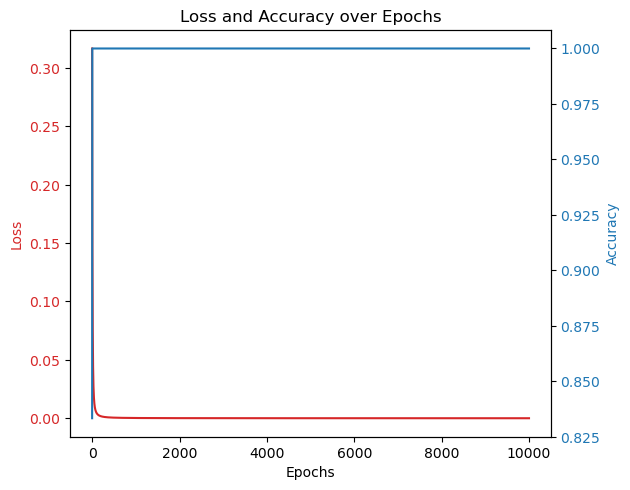

In [7]:
# Plotting the loss and accuracy over epochs
fig, ax1 = plt.subplots()

ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(range(epochs), losses, color='tab:red', label="Loss")
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.set_ylabel('Accuracy', color='tab:blue')  # we already handled the x-label with ax1
ax2.plot(range(epochs), accuracies, color='tab:blue', label="Accuracy")
ax2.tick_params(axis='y', labelcolor='tab:blue')

fig.tight_layout()  # adjust the layout to make space for both y-labels
plt.title("Loss and Accuracy over Epochs")
plt.show()


In [8]:
# Prediction on normalized input data
def predict(X):
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)  # Use ReLU for hidden layer
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)  # Sigmoid for output layer
    return A2 > 0.5  # Binary classification threshold at 0.5

# Predictions on training data
predictions = predict(X_normalized)
accuracy = np.mean(predictions == Y)
print(f"Training Accuracy: {accuracy * 100:.2f}%")

Training Accuracy: 100.00%


In [9]:
# Predict on new unseen input data (also normalize before predicting)
new_data = np.array([[28, 65000], [50, 130000]])  # New unseen data
new_data_normalized = (new_data - X_min) / (X_max - X_min)  # Normalize the new data
new_predictions = predict(new_data_normalized)
print("Predictions on new data:\n", new_predictions)

Predictions on new data:
 [[False]
 [ True]]
